In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [6]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
lattice_vectors = loadlattice("wannier.out")

3-element Vector{Vector{Float64}}:
 [7.4700742028, 0.0, 0.0]
 [-3.7350371014, 6.469294660399999, 0.0]
 [0.0, 0.0, 21.16708]

In [5]:
EsUp, _ = wannier_bands(HwannierUp, cell_mapUp, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));
EsDn, _ = wannier_bands(HwannierDn, cell_mapDn, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));

In [10]:
np.savetxt("EsUp.txt", EsUp)
np.savetxt("EsDn.txt", EsDn)

In [8]:
EnergiesUp, DOSUp = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)
EnergiesDn, DOSDn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)

([-25.719597049840853, -25.718597055630624, -25.717597061420395, -25.716597067210166, -25.71559707299994, -25.714597078789712, -25.713597084579483, -25.712597090369254, -25.711597096159025, -25.710597101948796  …  5.687221110806938, 5.688221105017167, 5.689221099227392, 5.690221093437621, 5.69122108764785, 5.692221081858079, 5.693221076068308, 5.694221070278537, 5.695221064488766, 5.696221058698995], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [9]:
np.savetxt("DosUp.txt", hcat(EnergiesUp, DOSUp))
np.savetxt("DosDn.txt", hcat(EnergiesDn, DOSDn))

In [48]:
epsilons = zeros(100, 100);
kpoints = bandstructkpoints2q(interpolate=5);
energies = collect(range(0, 100, length=1000*100));
landau_lower = zeros(60);
landau_upper = zeros(60);

In [49]:
for (i, k) in enumerate(kpoints[1:60])
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 0.5, length=100))
        epsilons[i, j] = imag(1 / ϵ(k, lattice_vectors, ω, energies, polarizations,  δ=0.001))
    end
end

In [50]:
plasmon = [range(0.05, 0.5, length=100)[argmax(x)] for x in eachrow(log.(abs.(epsilons[2:60, :])))]
qs, confinements = confinement(lattice_vectors, kpoints[2:60], plasmon);
plasmon = [0, plasmon...]
plasmon = smooth(plasmon, win_len = 20)
confinements = [0, confinements...];
confinements = smooth(confinements, win_len =20)
qs = [0, qs...];

In [53]:
for (i, k) in enumerate(kpoints[1:60])
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower[i] = maximum([filter(x-> x < plasmon[i], non_zero_impols)..., 0])
    landau_upper[i] = minimum(filter(x-> x > plasmon[i], non_zero_impols))
end

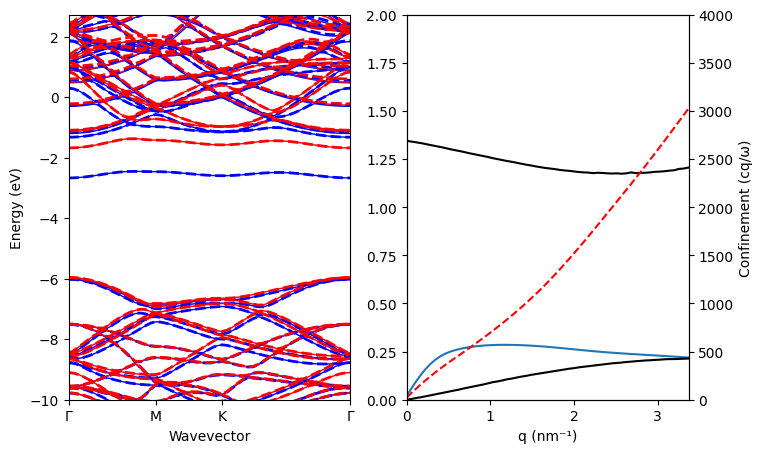

PyObject Text(738.9305555555555, 0.5, 'Confinement (cq/ω)')

In [58]:
figure(figsize=(8, 5))


subplot(1, 2, 1)
plot_bands("../BN33BC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cell_mapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")

ylim(-10, 0.1/eV)


subplot(1, 2, 2)
plot(qs*10, plasmon)
plot(qs*10, landau_lower, color="black")
plot(qs*10, landau_upper, color="black")

ylim(0, 2)
xlabel("q (nm⁻¹)")

twinx()
plot(qs*10, confinements, linestyle="dashed", color="red")
xlim(0, maximum(qs)*10)
ylim(0, 4000)
ylabel("Confinement (cq/ω)")

#yticks([0.2, 0.3])


In [68]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon, confinements))

In [59]:
np.savetxt("Landau.txt", hcat(qs, landau_lower, landau_upper))